<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Environment

In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

#example of a neural net by torch and numpy

##5x5 neural ntwork

In [ ]:
# @title
#define image - (batch)1x(channel)1x(3x3)
image = torch.tensor([[[[1.0, 42.0, 93.0],
                      [154.0, 175.0, 196.0],
                      [207.0, 228.0, 239.0]],
                      [[1.0, 42.0, 93.0],
                      [154.0, 175.0, 196.0],
                      [207.0, 228.0, 239.0]],
                      [[1.0, 42.0, 93.0],
                      [154.0, 175.0, 196.0],
                      [207.0, 228.0, 239.0]]]])

# image = torch.tensor([[[[1.0, 42.0, 93.0],
#                       [154.0, 175.0, 196.0],
#                       [207.0, 228.0, 239.0]]]] )
print(image.shape)

# Create a 2D conv layer: 1 input channel, 1 output channel, 2x2 kernel, no bias
conv = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=2, padding=1,stride=1, bias=False, dilation=1)

#padding - how many pixel of border you want to add; if 1 - a 3x3 input becomes 5x5, as 0,s are added all around
#stride - how many pixel you want to slide next; if 1 - kernel slide 1 pixel left

# Create a MaxPool2d layer (2x2 pool size, stride defaults to kernel_size if omitted)
max_pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=0)

# Method 1: Using the module
relu = nn.ReLU()

# Forward pass
output = conv(image)
print(output.shape)
max_output = max_pool(output)
print(max_output.shape)
relu_output = relu(max_output)
# print(relu_output)
print(relu_output.shape)

#ooutput = (in - dilation( kernel -1) +(2x padding))/stride +1

# Display the single channel grayscale image
# plt.imshow(output[0, 5].detach().numpy(), cmap='gray')
# plt.show()

torch.Size([1, 3, 3, 3])
torch.Size([1, 12, 4, 4])
torch.Size([1, 12, 3, 3])
torch.Size([1, 12, 3, 3])


In [70]:

class node:
  def __init__(self, data, prev=(), op='', label=''):
    self._data = data
    self._prev =set(prev)
    self._op = op
    self._label = label
    self._grad = 0.0
    self._backward = lambda : None

  def __repr__(self):
    return f"{self._data}"

  def __add__(self, others):
    others = others if isinstance (others,node) else node(others)
    out = node(self._data + others._data, (self, others), '+', label= f"{self._data} + {others._data}")

    def _backward():
      self._grad += 1*out._grad
      others._grad += 1*out._grad
    out._backward = _backward
    return out

  def __radd__(self, others):
    return self + others

  def __sub__(self, others):
    others = others if isinstance (others, node) else node(others)
    out = node(self._data - others._data, (self, others), '-', label= f"{self._data} - {others._data}")

    def _backward():
      self._grad += 1*out._grad
      others._grad += -1*out._grad
    out._backward = _backward
    return out

  def __rsub__(self,others):
    return -1*(self-others)

  def __mul__(self, others):
    others = others if isinstance (others, node) else node(others)
    out = node(self._data * others._data, (self, others), '*', label= f"{self._data}*{others._data}")
    def _backward():
      self._grad += others._data*out._grad
      others._grad += self._data*out._grad
    out._backward = _backward
    return out

  def __rmul__(self,others):
    return self*others

  def __neg__(self):
    return self * -1

  def __truediv__(self, others):
    others = others if isinstance (others, node) else node(others)
    out = node(self._data * others._data **-1, (self, others), '/', label=f"{self._data}/{others._data}")

    def _backward():
      self._grad += (others._data **-1)*out._grad
      others._grad += self._data * -1*(others._data ** -2) * out._grad

    out._backward = _backward
    return out

  def __rtruediv__(self, others):
    return (self/others)**-1

  def __pow__(self, others):
    assert isinstance(others, (int, float)), "only int and float are supported"
    out = node(self._data ** others, (self,), f"**{others}", label=f"{self._data}**{others}")

    def _backward():
      self._grad += others*(self._data**(others -1))*out._grad
    out._backward = _backward
    return out

  def backward(self):
    self._grad =1
    visited =[]
    topo=[]
    def build_topo(v):
      if v not in visited:
        visited.append(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    for node in reversed(topo):
      node._backward()

  def relu(self):
    # Use np.maximum to handle element-wise ReLU for potential array inputs
    out = node(np.maximum(0, self._data), (self,), 'relu', label=f"relu {self._data}")
    def _backward():
      self._grad += (self._data > 0) * out._grad # Derivative is 1 if >0, 0 otherwise
    out._backward = _backward
    return out

  def log(self):
    """Calculates the natural logarithm (ln) of the node's data."""
    # Ensure numerical stability: add a small epsilon to prevent log(0)
    epsilon = 1e-12
    out = node(np.log(self._data + epsilon), (self,), 'log', label=f"log {self._data}")

    def _backward():
        # dL/dx = dL/d_out * d_out/dx
        # d(log x)/dx = 1/x
        self._grad += (1 / (self._data + epsilon)) * out._grad
    out._backward = _backward
    return out

  def exp(self):
    """Calculates the exponential (e^x) of the node's data."""
    out = node(np.exp(self._data), (self,), 'exp', label=f"exp {self._data}")

    def _backward():
        # dL/dx = dL/d_out * d_out/dx
        # d(exp x)/dx = exp x
        self._grad += np.exp(self._data) * out._grad # Or out._data * out._grad
    out._backward = _backward
    return out

  def _zero_grad(self):
    self._grad = 0.0



In [71]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p._grad = 0.0

    def parameters(self):
        return []

In [72]:
class neuron(Module):
  # def __init__(self, n_wt, nonlin=True):

  def __init__(self, n_wt, nonlin=True, rng=None):
    super().__init__()
    # templae = np.random.default_rng(seed=50)
    # self.w = [node(templae.random())for _ in range(n_wt)]
    # self.bias = node(templae.random())

    # self.bias = node(templae.random())
    if rng is None:
        # Fallback to unseeded rng if not provided (though in this context, it will be provided)
        rng = np.random.default_rng()
    # Initialize weights and biases using a uniform distribution between -1 and 1
    self.w = [node(rng.uniform(-1, 1))for _ in range(n_wt)]
    self.bias = node(rng.uniform(-1, 1))
    self.nonlin = nonlin

  def __call__(self, _in):
    # `w` is a node, `_inp` is a plain number. `w * _inp` calls `w.__mul__(_inp)`,
    # which correctly handles the scalar `_inp` and returns a new node.
    weighted_inputs = (w * _inp for w, _inp in zip(self.w, _in))
    o = sum(weighted_inputs, self.bias)
    return o.relu() if self.nonlin else o

  def parameter(self):
    return self.w + [self.bias]

class layer:
  def __init__(self, n_wt, n_neu_l, nonlin=True, rng=None):
    self.l = [neuron(n_wt, nonlin, rng=rng)for _ in range(n_neu_l)]

  def __call__(self, _in):
    o = [neu(_in) for neu in self.l]
    return o

  def parameter(self):
    return [wt for neu in self.l for wt in neu.parameter()]

class mlayer(Module):
  # def __init__(self, n_wt, n_nu_l, n_ml):

  def __init__(self, n_wt, n_nu_l, n_ml, rng=None):
    super().__init__() # Call the constructor of the base class (Module)
    # self.ml = [layer(n_wt, n_nu_l) for _ in range(n_ml)]


    if rng is None:
        rng = np.random.default_rng()
    self.ml = []
    for i in range(n_ml):
        is_last_layer = (i == n_ml - 1)
        # self.ml.append(layer(n_wt, n_nu_l, nonlin=not is_last_layer)) # Apply nonlin to all but the last layer

        # Pass the rng instance down to the layer, which will then pass it to neurons
        self.ml.append(layer(n_wt, n_nu_l, nonlin=not is_last_layer, rng=rng))

  def __call__(self, _in):
    for layer in self.ml:
      _in = layer(_in)
    o = _in
    return o

  def parameter(self):
    return [neuron for layer in self.ml for neuron in layer.parameter()]

  def gradient(self):
    return np.array([neuron._grad for layer in self.ml for neuron in layer.parameter()])#for wt in neuron]

### Andrej Karpathy-style Softmax Implementation

This section demonstrates a `SoftmaxLayerK` class, implemented in the style of Andrej Karpathy's micrograd. It operates on a *list* of individual `node` objects (each assumed to hold a scalar value), rather than a single `node` whose `_data` attribute contains an array. This design explicitly constructs the computational graph by linking each output `node` to all input `node`s.


 Demonstration of `SoftmaxLayerK`

In [73]:
import numpy as np

# Assuming the 'node' class (from cell zF2zRqsDDXU1) and 'Module' class (from cell 743e7c2b)
# are already defined and available in the environment.
# class Module():

class SoftmaxLayerK(Module):
    """
    A Karpathy-style softmax implementation as a Module.
    It takes a list of scalar `node` objects as input and returns a list of scalar `node` objects.
    This mimics the structure where each individual scalar `node` is explicitly linked
    in the computation graph.
    """
    def __init__(self):
        super().__init__()
        # Softmax itself has no learnable parameters

    def __call__(self, inputs_nodes_list):
        # inputs_nodes_list: A list of 'node' objects (e.g., [node(z1), node(z2), ...])
        # Each node is assumed to hold a scalar `_data` for this context,
        # adhering to the original micrograd Value design philosophy.

        z_values = np.array([n._data for n in inputs_nodes_list])

        # Apply numerical stability trick for softmax
        max_z = np.max(z_values)
        exp_z = np.exp(z_values - max_z)
        sum_exp_z = np.sum(exp_z)
        s_values = exp_z / sum_exp_z # These are the softmax outputs (numpy array)

        output_nodes = []
        for i, s_val in enumerate(s_values):
            # Create a new node for each softmax output
            # All input nodes are parents to each output node
            out_node = node(s_val, prev=tuple(inputs_nodes_list), op='softmax_output', label=f'softmax_out_{i}')
            output_nodes.append(out_node)

            # Define the _backward function for this specific output_node
            # This _backward captures references to its own output node, all input nodes,
            # and the full array of softmax outputs (s_values) at the time of the forward pass.
            # FIX: Use default arguments to correctly capture the value of 'i' for each closure instance
            def _backward(current_output_node=out_node, all_input_nodes=inputs_nodes_list, full_s_values_array=s_values, current_i=i):
                dL_ds_i = current_output_node._grad # Gradient coming into this specific output s_i

                s_i_val = current_output_node._data # The scalar value of this output node

                for j, input_node_j in enumerate(all_input_nodes):
                    s_j_val = full_s_values_array[j] # The scalar value of softmax output s_j

                    # Calculate ds_i/dz_j (partial derivative of softmax output s_i w.r.t input z_j)
                    if current_i == j: # if s_i is being differentiated w.r.t. its own input z_i
                        ds_i_dz_j = s_i_val * (1 - s_i_val)
                    else: # if s_i is being differentiated w.r.t. a different input z_j
                        ds_i_dz_j = -s_i_val * s_j_val

                    # Accumulate the gradient on the corresponding input node
                    input_node_j._grad += dL_ds_i * ds_i_dz_j

            out_node._backward = _backward

        return output_nodes

    def parameters(self):
        # Softmax layer itself has no learnable parameters
        return []

In [74]:
class cross_entropy_loss:
  def __call__(self, _o_logits, _t_o):
    # _o_logits is a list of node objects
    # 1. Numerically stable log-softmax computation
    # Find the maximum logit for stability (as a Node for graph)
    # We need to get the data values to find the max using numpy
    max_logit_data = np.max([n._data for n in _o_logits])
    # Create a temporary node for the max_logit_data, but it doesn't need to be part of the backward graph for stability purposes
    # if the subtraction is handled correctly (each logit node is a parent)

    # Subtract max_logit from each logit and exponentiate
    exp_logits = []
    shifted_logits_nodes = [] # Store shifted logit nodes for correct log_softmax calculation
    for l_node in _o_logits:
        # Ensure subtraction is done with a node for graph building, even if it's a constant node
        shifted_l_node = l_node - node(max_logit_data) # This subtraction creates new nodes
        shifted_logits_nodes.append(shifted_l_node)
        exp_logits.append(shifted_l_node.exp())   # This exp creates new nodes #0 to 1

    # Sum the exponentiated logits
    sum_exp_logits = sum(exp_logits) # This sum creates new nodes

    # Take the log of the sum for log-softmax denominator
    log_sum_exp_logits = sum_exp_logits.log() # This log creates a new node#>1 =+ve; >0 and <1 = -ve;; -ve then infinitr

    # Calculate log-softmax outputs
    log_softmax_outputs = []
    for shifted_l_node in shifted_logits_nodes: # Use the shifted logit node
        log_softmax_outputs.append(shifted_l_node - log_sum_exp_logits) # This subtraction creates new nodes

    # 2. Cross-entropy loss
    target_array = np.array(_t_o)
    cross_entropy_terms = []

    for i, log_p_node in enumerate(log_softmax_outputs):
        if target_array[i] == 1: # Only consider the term for the correct class in one-hot encoding
            # The term is -1 * log(probability) for the correct class.
            # log_p_node already represents log(probability).
            term = -1 * log_p_node
            cross_entropy_terms.append(term)

    total_loss = sum(cross_entropy_terms)
    return total_loss

In [75]:
class mse_loss:
  def __call__(self, prediction, target, num_classes=10):
    """
    prediction = [10 values] - list of 10 nodes
    target = integer between 0 to 9
    """

    total_loss = node(0.0) # Initialize total_loss as a node object#error
    for idx in range(num_classes):
      target_val=1.0 if target == idx else 0.0
      total_loss += (prediction[idx] - target_val)**2
    return total_loss * (1.0 / num_classes)

In [ ]:
# @title
# Create some dummy input nodes (each holding a scalar value)
input_nodes_k = [
    node(0.5, label='z1'),
    node(2.0, label='z2'),
    node(1.0, label='z3')
]

# Instantiate the Karpathy-style Softmax layer
softmax_layer_k = SoftmaxLayerK()

# Perform the forward pass
output_nodes_k = softmax_layer_k(input_nodes_k)

print("Input nodes:", [n._data for n in input_nodes_k])
print("Output nodes (softmax probabilities):")
for n in output_nodes_k:
    print(f"  {n._label}: {n._data}")

# --- Demonstrate Backward Pass ---

# To perform backward pass, we need a 'loss' node. Let's create a dummy one.
# For example, sum all outputs and backprop from there, setting grad=1 for the sum.
# This is equivalent to having a loss that wants each output to increase.
loss_k = sum(output_nodes_k)
loss_k.backward()

print("\nGradients after backward pass:")
for n in input_nodes_k:
    print(f"  Input {n._label} _grad: {n._grad}")

# Demonstrate zero_grad
softmax_layer_k.zero_grad() # This won't do anything as softmax has no params

# To zero gradients of inputs to the softmax, you would need to zero the gradients
# of the parameters that produced these inputs (e.g., weights/biases in a preceding layer).
# For this demonstration, we can manually zero the input node gradients if needed.
for n in input_nodes_k:
    n._grad = 0.0

print("\nGradients of input nodes after manual zero_grad:")
for n in input_nodes_k:
    print(f"  Input {n._label} _grad: {n._grad}")

Input nodes: [0.5, 2.0, 1.0]
Output nodes (softmax probabilities):
  softmax_out_0: 0.14024438316608848
  softmax_out_1: 0.6285317192117624
  softmax_out_2: 0.23122389762214907

Gradients after backward pass:
  Input z1 _grad: -0.14024438316608848
  Input z2 _grad: -0.6285317192117624
  Input z3 _grad: 0.5318149001034915

Gradients of input nodes after manual zero_grad:
  Input z1 _grad: 0.0
  Input z2 _grad: 0.0
  Input z3 _grad: 0.0


In [ ]:
# @title
import numpy as np

# --- Updated node class (no _zero_grad method here) ---
class Node:
  def __init__(self, data, prev=(), op='', label=''):
    self._data = data
    self._prev =set(prev)
    self._op = op
    self._label = label
    self._grad = 0.0
    self._backward = lambda : None

  def __repr__(self):
    return f"Node({self._data})"

  def __add__(self, others):
    others = others if isinstance (others,Node) else Node(others)
    out = Node(self._data + others._data, (self, others), '+', label= f"{self._data} + {others._data}")

    def _backward():
      self._grad += 1*out._grad
      others._grad += 1*out._grad
    out._backward = _backward
    return out

  def __radd__(self, others):
    return self + others

  def __sub__(self, others):
    others = others if isinstance (others, Node) else Node(others)
    out = Node(self._data - others._data, (self, others), '-', label= f"{self._data} - {others._data}")

    def _backward():
      self._grad += 1*out._grad
      others._grad += -1*out._grad
    out._backward = _backward
    return out

  def __rsub__(self,others):
    return -1*(self-others)

  def __mul__(self, others):
    others = others if isinstance (others, Node) else Node(others)
    out = Node(self._data * others._data, (self, others), '*', label= f"{self._data}*{others._data}")
    def _backward():
      self._grad += others._data*out._grad
      others._grad += self._data*out._grad
    out._backward = _backward
    return out

  def __rmul__(self,others):
    return self*others

  def __neg__(self):
    return self * -1

  def __truediv__(self, others):
    others = others if isinstance (others, Node) else Node(others)
    out = Node(self._data * others._data **-1, (self, others), '/', label=f"{self._data}/{others._data}")

    def _backward():
      self._grad += (others._data **-1)*out._grad
      others._grad += self._data * -1*(others._data ** -2) * out._grad

    out._backward = _backward
    return out

  def __rtruediv__(self, others):
    return (self/others)**-1

  def __pow__(self, others):
    assert isinstance(others, (int, float)), "only int and float are supported"
    out = Node(self._data ** others, (self,), f"**{others}", label=f"{self._data}**{others}")

    def _backward():
      self._grad += others*(self._data**(others -1))*out._grad
    out._backward = _backward
    return out

  def backward(self):
    self._grad =1
    visited =[]
    topo=[]
    def build_topo(v):
      if v not in visited:
        visited.append(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    for node_elem in reversed(topo):
      node_elem._backward()

  def relu(self):
    out = Node(np.maximum(0, self._data), (self,), 'relu', label=f"relu {self._data}")
    def _backward():
      self._grad += (self._data > 0) * out._grad
    out._backward = _backward
    return out

In [ ]:
# @title
import random

# --- Module class ---
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p._grad = 0.0

    def parameters(self):
        return []

# --- Neuron class inheriting from Module ---
class Neuron(Module):
    def __init__(self, nin, nonlin=True):
        # Changed Value to Node to match your Node class
        self.w = [Node(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Node(0)
        self.nonlin = nonlin

    def __call__(self, x):
        # x here is assumed to be a list of numerical inputs
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

# --- Layer class inheriting from Module ---
class Layer(Module):
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        params = []
        for neuron_inst in self.neurons:
            params.extend(neuron_inst.parameters())
        return params

# --- MLP class (Multi-Layer Perceptron) inheriting from Module ---
class MLP(Module):
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = []
        for i in range(len(nouts)):
            # Last layer has no nonlinearity usually for regression, but can be for classification
            # For simplicity, assuming all layers have nonlin for now based on your neuron's default
            self.layers.append(Layer(sz[i], sz[i+1], nonlin=True))

    def __call__(self, x):
        for layer_inst in self.layers:
            # If layer output is a single Node, x becomes that Node
            # If layer output is a list of Nodes, x becomes that list
            # This assumes that subsequent layers can handle list of Nodes or single Node as input
            x = layer_inst(x)
        return x

    def parameters(self):
        params = []
        for layer_inst in self.layers:
            params.extend(layer_inst.parameters())
        return params

In [ ]:
# @title
# Example usage of the new classes

# Define an MLP
# Input size 3, then 2 layers with 4 neurons each, and a final output layer with 1 neuron
n_inputs = 3
n_hidden_layers = [4, 4, 1] # Two hidden layers with 4 neurons, one output neuron
mlp_model = MLP(n_inputs, n_hidden_layers)

print(f"Total parameters in MLP: {len(mlp_model.parameters())}")

# Create some dummy inputs (list of numbers)
x_input = [Node(2.0), Node(3.0), Node(-1.0)]

# Forward pass
y_pred = mlp_model(x_input)
print(f"\nMLP output for input {x_input}: {y_pred}")

# Perform a backward pass to get gradients
# Assuming y_pred is a list of Nodes for multi-output or a single Node for single output
if isinstance(y_pred, list):
    # For simplicity, backprop from the sum of outputs if multiple outputs
    loss = sum(y_pred)
else:
    loss = y_pred # If it's a single Node output

loss.backward()

print(f"\nGradients of first 5 parameters before zero_grad: {[p._grad for p in mlp_model.parameters()[:5]]}")

# Now, use the zero_grad method from the Module class
mlp_model.zero_grad()

print(f"Gradients of first 5 parameters after zero_grad: {[p._grad for p in mlp_model.parameters()[:5]]}")


Total parameters in MLP: 41

MLP output for input [Node(2.0), Node(3.0), Node(-1.0)]: Node(0.0)

Gradients of first 5 parameters before zero_grad: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Gradients of first 5 parameters after zero_grad: [0.0, 0.0, 0.0, 0.0, 0.0]


###testing

In [ ]:
# @title
templa = np.random.default_rng(seed=50)
# _in = templa.uniform(low=5, high=9, size=(3,2))

# Changed to a 1D array of n_wt features for the neuron
# _in_r = templa.random(n_wt)
# _in_r = [1, 0, 0, 0, 0]
''',
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1]]'''
# _t_o = [1, 0, 0, 0, 0]
''',
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1]]'''
# print(_in_r)


####neuron
# # _in_r_1 = templa.uniform(low=0, high=1, size=(1,5))
# n_wt=5
# _neuron = neuron(n_wt)
# a = _neuron(_in_r)
# print(a)
# print(_neuron.parameter())
# print(_in_r)
# # print(_in_r_1) # This line was commented out or used an undefined variable.
# _in_node = node(_in_r)


# ##layer
# n_wt=5
# _layer = layer(n_wt, n_wt)
# o = _layer(_in_r)
# print(o)


n_wt=5

##multilayer
# _mlayer = mlayer(n_wt, n_wt, n_wt)

# _mlayer = mlayer(n_wt, n_wt, n_wt, rng=templa) # Pass the templa rng instance
_mlayer = mlayer(n_wt, n_wt, n_wt, rng=templa)

#5 layer x 5 layer x 5layer -> 5 output

In [ ]:
_in_r = [1, 0, 0, 0, 0]
_t_o = [1, 0, 0, 0, 0]

# for _in in _in_r:
o = _mlayer(_in_r)
#######work on loss and make a small model, if you give 1, it give back 1 and so on, you can try tables, etc

# # Create a single Node from the list of output nodes to apply softmax
# # Assuming o is a list of node objects like [Node(val1), Node(val2), ...]
# if isinstance(o, list):
#     # Extract the data from each node and create a new composite node
#     composite_data = np.array([node_obj._data for node_obj in o])
#     o_composite = node(composite_data, prev=tuple(o), op='composite_output')
# else:
#     o_composite = o # If it's already a single node, use it directly

# o_softmax = o_composite.softmax()
o_softmax = SoftmaxLayerK()

o_soft_o = o_softmax(o)

print(f"input: {_in_r}")
print(f"target: {_t_o}")
print(f"Output of mlayer: {o}")
print(f"output after softmax: {o_soft_o}")
# print(f"Parameters of mlayer: {(_mlayer.parameter())}")
print(f"Gradient of mlayer: {(_mlayer.gradient())}")
print(f"Total parameters: {len(_mlayer.gradient())}")

input: [1, 0, 0, 0, 0]
target: [1, 0, 0, 0, 0]
Output of mlayer: [-0.7855882132113821, -0.9419350641409215, -0.09870949195748052, -0.4405328792531166, 0.19290761481777516]
output after softmax: [0.12633785007769469, 0.10805202428024578, 0.25109676672148706, 0.1783976419567555, 0.336115716963817]
Gradient of mlayer: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Total parameters: 150


In [ ]:

Loss_func = loss()
total_loss = Loss_func(o_soft_o, _t_o)

print(f"Target nodes: {[t._data for t in [node(t) for t in _t_o]]}")
print(f"Softmax output nodes: {[o._data for o in o_soft_o]}")
print(f"Total Loss: {total_loss._data}")
# print(f"Gradient of total_loss: {total_loss._grad}") # This will be 0 before backward

Target nodes: [1, 0, 0, 0, 0]
Softmax output nodes: [np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2)]
Total Loss: 0.8000000000000003


In [ ]:
# print(f"Gradient of mlayer -before backward: {_mlayer.gradient()}")

# Perform backward pass on the single scalar total_loss
total_loss.backward()

# print(f"Gradient of mlayer -after backward: {_mlayer.gradient()}")

Gradient of mlayer -before backward: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Gradient of mlayer -after backward: [-4.99155999e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -4.99155999e-16 -5.28472260e-16  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -5.28472260e-16
 -3.47322729e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -3.47322729e-16 -6.17080205e-16  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -6.17080205e-16
 -1.50131426e-16  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+

In [ ]:
# learning_rate = 1e-5 # Reduced the learning rate to prevent exploding parameters
# learning_rate = 1e-1 # Reduced the learning rate to prevent exploding parameters
learning_rate = 1e-3 # Reduced the learning rate to prevent exploding parameters

# Update parameters
for p in _mlayer.parameter():
    p._data -= learning_rate * p._grad


In [ ]:
for p in _mlayer.parameter(): p._zero_grad()
print(f"Gradient of mlayer: {_mlayer.gradient()}")


Gradient of mlayer: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


repeat

Epoch 0, Average Loss: 0.7964884516150661
Epoch 10, Average Loss: 0.7910687731293937
Epoch 20, Average Loss: 0.7863869925938555
Epoch 30, Average Loss: 0.7822838781660346
Epoch 40, Average Loss: 0.7786484844480358
Epoch 50, Average Loss: 0.7753864541696001
Epoch 60, Average Loss: 0.7724449748477737
Epoch 70, Average Loss: 0.7697625866792788
Epoch 80, Average Loss: 0.7673105185643854
Epoch 90, Average Loss: 0.7650555396194365
Epoch 100, Average Loss: 0.762973981991806
Epoch 110, Average Loss: 0.76104211151306
Epoch 120, Average Loss: 0.7592427396414084
Epoch 130, Average Loss: 0.7575620675833703
Epoch 140, Average Loss: 0.7559888132818036
Epoch 150, Average Loss: 0.7545095723149926
Epoch 160, Average Loss: 0.753116432374233
Epoch 170, Average Loss: 0.7518014038437179
Epoch 180, Average Loss: 0.7505574420391393
Epoch 190, Average Loss: 0.7493796463139788
Epoch 200, Average Loss: 0.7482598913860048
Epoch 210, Average Loss: 0.74719471901499
Epoch 220, Average Loss: 0.7461798703039004
Epoch

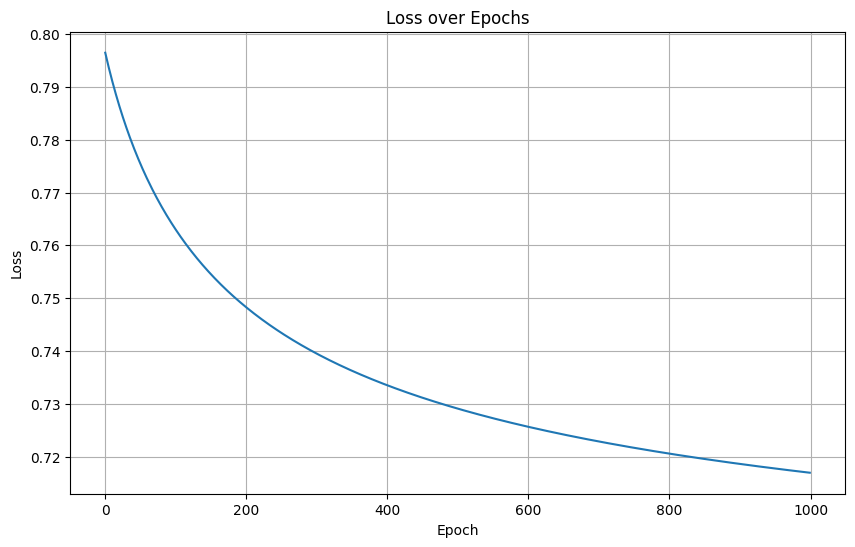

In [ ]:
# n_wt=5
# _mlayer = mlayer(n_wt, n_wt, n_wt)

# Moved _mlayer initialization outside the epoch loop to ensure continuous learning
# _mlayer = mlayer(n_wt, n_wt, n_wt, rng=templa)

_in = [[1, 0, 0, 0, 0],
      [0, 1, 0, 0, 0],
      [0, 0, 1, 0, 0],
      [0, 0, 0, 1, 0],
      [0, 0, 0, 0, 1]]
_ot = [[1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]]

losses = [] # List to store loss values per epoch

for epoc in range(1000): # Increased epochs for better observation
  epoch_losses = [] # Store losses for each input within an epoch
  for _in_r,_t_o in zip(_in,_ot):
    # for _in in _in_r:
    o = _mlayer(_in_r) # 'o' now contains raw logits from mlayer
    #######work on loss and make a small model, if you give 1, it give back 1 and so on, you can try tables, etc

    # Instantiate SoftmaxLayerK and compute softmax outputs for display purposes
    temp_softmax_layer = SoftmaxLayerK()
    o_soft_o_display = temp_softmax_layer(o)

    Loss_func = loss()
    # Pass raw logits 'o' directly to the loss function
    total_loss = Loss_func(o, _t_o)

    # print(f"input: {_in_r}")
    # print(f"target: {_t_o}")
    # print(f"Output of mlayer (logits): {o}") # Label changed to reflect logits
    # The softmax output is no longer explicitly computed and printed separately, as it's part of the loss calculation.
    # If needed for monitoring, SoftmaxLayerK could still be used outside the main training loop for evaluation.

    # print(f"Total parameters: {len(_mlayer.gradient())}")
    # Print the dynamically computed softmax output nodes
    # print(f"Softmax output probabilities: {[s_node._data for s_node in o_soft_o_display]}")
    epoch_losses.append(total_loss._data)

    total_loss.backward()

    # learning_rate = 1e-6 # Reduced the learning rate further
    # learning_rate = 1e-2 # Reduced the learning rate to prevent exploding parameters
    learning_rate = 1e-1 # Increased learning rate to encourage faster convergence
    # learning_rate = 1e-4 # Reduced the learning rate to prevent exploding parameters


    # Update parameters
    for p in _mlayer.parameter():
        p._data -= learning_rate * p._grad

    #zero grad
    for p in _mlayer.parameter(): p._zero_grad()
  losses.append(np.mean(epoch_losses)) # Store the average loss for the epoch
  if epoc % 10 == 0: # Print loss every 10 epochs
      print(f"Epoch {epoc}, Average Loss: {losses[-1]}")

print(f"Final Average Loss: {losses[-1]}")

# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.grid(True)
plt.show()

## Test the Trained Model

Now, let's use the trained `_mlayer` to make a prediction on a new input. We'll pass an input through the model to get the raw logits, then apply the `SoftmaxLayerK` to convert these logits into probabilities, and finally determine the predicted class based on the highest probability.

In [ ]:
# Define a test input (e.g., the first input from our training set)
test_input = [0, 0, 0, 0, 1]

# Pass the test input through the trained _mlayer to get logits
test_logits = _mlayer(test_input)

# Instantiate SoftmaxLayerK and compute softmax probabilities from the logits
test_softmax_layer = SoftmaxLayerK()
test_probabilities = test_softmax_layer(test_logits)

# Extract the data from the probability nodes
prob_values = [p._data for p in test_probabilities]

print(f"Test Input: {test_input}")
print(f"Raw Logits: {[l._data for l in test_logits]}")
print(f"Predicted Probabilities: {prob_values}")

# Determine the predicted class (index with the highest probability)
predicted_class_index = np.argmax(prob_values)
print(f"Predicted Class Index: {predicted_class_index}")

Test Input: [0, 0, 0, 0, 1]
Raw Logits: [np.float64(-5.782845884124827), np.float64(-5.176804605948371), np.float64(-6.083128479614213), np.float64(-1.96576914636347), np.float64(5.203748524177173)]
Predicted Probabilities: [np.float64(1.6913063417737935e-05), np.float64(3.100435209540927e-05), np.float64(1.25259652659111e-05), np.float64(0.000769055427584101), np.float64(0.999170501191637)]
Predicted Class Index: 4


### Applying the Learning Rate and Zeroing Gradients

After computing the loss and performing the `backward()` pass, the `_grad` attribute of each `node` representing a parameter (weights and biases) contains its gradient. To update these parameters, we use an optimizer (though here we'll do it manually) and a learning rate. After the update, it's crucial to `zero_grad()` on all parameters so that gradients don't accumulate from previous steps in the next backward pass.

In [ ]:
learning_rate = 1e-5 # Reduced the learning rate to prevent exploding parameters

# IMPORTANT: Zero the gradients before computing new ones for the current step
for p in _mlayer.parameter(): p._zero_grad()
# _mlayer.zero_grad()

print("Parameters before update (first 5):")
for p in _mlayer.parameter()[:5]:
    print(f"  {p._label if p._label else 'Unnamed Parameter'}: {p._data}")

# Re-evaluate forward pass to ensure total_loss is fresh (if not done immediately before)
# This is already handled by the execution flow where k6pfA5WkGKfo runs before this cell.

# Perform backward pass on the single scalar total_loss
total_loss.backward()

# Update parameters
for p in _mlayer.parameter():
    p._data -= learning_rate * p._grad

print("\nParameters after update (first 5):")
for p in _mlayer.parameter()[:5]:
    print(f"  {p._label if p._label else 'Unnamed Parameter'}: {p._data}")

# We will rely on the subsequent cell (dEcsYtJyEtxa) for explicit zeroing of gradients.
# However, the zeroing before backward() is the critical part for correct training steps.
print(f"\nGradients (first 5) after backward and update: {[p._grad for p in _mlayer.parameter()[:5]]}")
print(f"Softmax output nodes: {[o._data for o in o_soft_o]}")


Parameters before update (first 5):
  Unnamed Parameter: 3.8687888378229563e+70
  Unnamed Parameter: 0.8336693345835825
  Unnamed Parameter: 0.547904460184225
  Unnamed Parameter: 0.9734490961401129
  Unnamed Parameter: 0.23683355791235983

Parameters after update (first 5):
  Unnamed Parameter: 3.8687888378229563e+70
  Unnamed Parameter: 0.8336693345835825
  Unnamed Parameter: 0.547904460184225
  Unnamed Parameter: 0.9734490961401129
  Unnamed Parameter: 0.23683355791235983

Gradients (first 5) after backward and update: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
Softmax output nodes: [np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [ ]:
param = Module()
param.parameters()

[]

### Illustrating Parent-Child Class Inheritance

This example shows a `Parent` class with some basic functionality and a `Child` class that inherits from it. The `Child` class automatically gains the methods and properties of the `Parent` class without needing to redefine them, demonstrating the power of code reuse through inheritance.

In [ ]:
class Parent:
    def __init__(self, name):
        self._name = name
        self._common_attribute = "I am a common attribute from Parent."

    def get_name(self):
        return f"My name is {self._name} (from Parent class)."

    def get_common_attribute(self):
        return self._common_attribute

    def introduce(self):
        return f"Hello, {self._name}!"


class Child(Parent):
    def __init__(self, name, favorite_toy):
        # Call the parent's constructor to initialize inherited attributes
        super().__init__(name)
        self._favorite_toy = favorite_toy

    # The Child class automatically inherits get_name(), get_common_attribute(), and introduce()
    # We can also add new methods specific to the Child class
    def play_with_toy(self):
        return f"{self._name} is playing with their {self._favorite_toy}."

    # We can also override a parent's method if needed
    def introduce(self):
        # We can still call the parent's method from here if we want
        parent_intro = super().introduce()
        return f"{parent_intro} I am also a child and I love {self._favorite_toy}!"


# Create instances
parent_obj = Parent("Alice")
child_obj = Child("Bob", "Lego")

print("--- Parent Object ---")
print(parent_obj.get_name())
print(parent_obj.get_common_attribute())
print(parent_obj.introduce())

print("\n--- Child Object ---")
print(child_obj.get_name()) # Method inherited from Parent
print(child_obj.get_common_attribute()) # Attribute inherited from Parent
print(child_obj.play_with_toy()) # New method in Child
print(child_obj.introduce()) # Overridden method in Child

--- Parent Object ---
My name is Alice (from Parent class).
I am a common attribute from Parent.
Hello, Alice!

--- Child Object ---
My name is Bob (from Parent class).
I am a common attribute from Parent.
Bob is playing with their Lego.
Hello, Bob! I am also a child and I love Lego!


In [ ]:
# 1. Simple Inheritance (Single Base Class)
class Animal:
    def __init__(self, name):
        self.name = name
        self.species = "Animal"

    def speak(self):
        return "Some animal sound"

    def get_info(self):
        return f"{self.name} is a {self.species}."

class Dog(Animal):
    def __init__(self, name, breed):
        super().__init__(name) # Call parent's __init__
        self.breed = breed
        self.species = "Dog" # Override parent attribute

    def speak(self):
        return "Woof!"

    def fetch(self):
        return f"{self.name} is fetching the ball."

dog = Dog("Buddy", "Golden Retriever")
print("--- Simple Inheritance ---")
print(dog.get_info()) # Inherited method
print(dog.speak())    # Overridden method
print(dog.fetch())    # Child's own method
print()


# 2. Multiple Inheritance
# (Inheriting from more than one base class)

class Swimmer:
    def swim(self):
        return "I can swim!"

class Flyer:
    def fly(self):
        return "I can fly!"

class Duck(Swimmer, Flyer):
    def __init__(self, name):
        self.name = name

    def quack(self):
        return f"{self.name} says Quack!"

duck = Duck("Daffy")
print("--- Multiple Inheritance ---")
print(duck.quack())
print(duck.swim()) # Inherited from Swimmer
print(duck.fly())  # Inherited from Flyer
print()


# 3. Inheritance with Explicit Parent Method Calls (using super() for specific methods)
class Logger:
    def log(self, message):
        return f"[LOG] {message}"

class AdvancedLogger(Logger):
    def log(self, message, level="INFO"):
        # Call the parent's log method, but add extra info
        parent_log = super().log(message)
        return f"[{level}] {parent_log}"

adv_logger = AdvancedLogger()
print("--- Explicit Parent Method Calls ---")
print(adv_logger.log("This is a test.", level="DEBUG"))
print(adv_logger.log("Another message.")) # Default level


--- Simple Inheritance ---
Buddy is a Dog.
Woof!
Buddy is fetching the ball.

--- Multiple Inheritance ---
Daffy says Quack!
I can swim!
I can fly!

--- Explicit Parent Method Calls ---
[DEBUG] [LOG] This is a test.
[INFO] [LOG] Another message.


## PyTorch Implementation

This section re-implements the neural network using PyTorch's `nn.Module` for defining the model architecture and its automatic differentiation capabilities. We will define a 5-layer MLP, with 5 neurons in each of the four hidden layers and 5 neurons in the output layer for a 5-class classification problem. We will then set up a training loop using `nn.CrossEntropyLoss` and an optimizer.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the PyTorch MLP model
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(hidden_size, hidden_size)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(hidden_size, hidden_size)
        self.relu4 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, output_size) # 5 output neurons for 5 classes

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.relu4(self.layer4(x))
        x = self.output_layer(x)
        return x

# Model parameters based on previous custom model
n_wt = 5  # Input features
hidden_neurons = 5
output_neurons = 5 # For 5-class classification

# Instantiate the PyTorch model
model = PyTorchMLP(n_wt, hidden_neurons, output_neurons)
print(f"PyTorch Model: {model}")
print(f"Total parameters in PyTorch MLP: {sum(p.numel() for p in model.parameters())}")

PyTorch Model: PyTorchMLP(
  (layer1): Linear(in_features=5, out_features=5, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=5, out_features=5, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=5, out_features=5, bias=True)
  (relu3): ReLU()
  (layer4): Linear(in_features=5, out_features=5, bias=True)
  (relu4): ReLU()
  (output_layer): Linear(in_features=5, out_features=5, bias=True)
)
Total parameters in PyTorch MLP: 150


In [ ]:
# Prepare data as PyTorch tensors
# Input data: 5 samples, each with 5 features
_in = torch.tensor([
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]
], dtype=torch.float32)

# Target data: class indices for nn.CrossEntropyLoss
# For one-hot target like [1,0,0,0,0], the index is 0.
_ot = torch.tensor([0, 1, 2, 3, 4], dtype=torch.long)

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Using Adam optimizer

# Training Loop
epochs = 1000
losses_pytorch = []

print("\nStarting PyTorch training...")
for epoch in range(epochs):
    epoch_losses_batch = []
    for i in range(len(_in)):
        input_data = _in[i].unsqueeze(0) # Add batch dimension
        target_data = _ot[i].unsqueeze(0) # Add batch dimension

        # print(f"Input: {input_data}")
        # print(f"Target: {target_data}")

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_data)

        # Calculate loss
        loss = criterion(outputs, target_data)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_losses_batch.append(loss.item())
        # print(loss.item())

    avg_epoch_loss = sum(epoch_losses_batch) / len(epoch_losses_batch)
    losses_pytorch.append(avg_epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_epoch_loss:.4f}')

print(f"Final PyTorch Average Loss: {losses_pytorch[-1]:.4f}")


Starting PyTorch training...
Epoch [100/1000], Loss: 0.0589
Epoch [200/1000], Loss: 0.0402
Epoch [300/1000], Loss: 0.0290
Epoch [400/1000], Loss: 0.0216
Epoch [500/1000], Loss: 0.0165
Epoch [600/1000], Loss: 0.0128
Epoch [700/1000], Loss: 0.0061
Epoch [800/1000], Loss: 0.0004
Epoch [900/1000], Loss: 0.0001
Epoch [1000/1000], Loss: 0.0000
Final PyTorch Average Loss: 0.0000


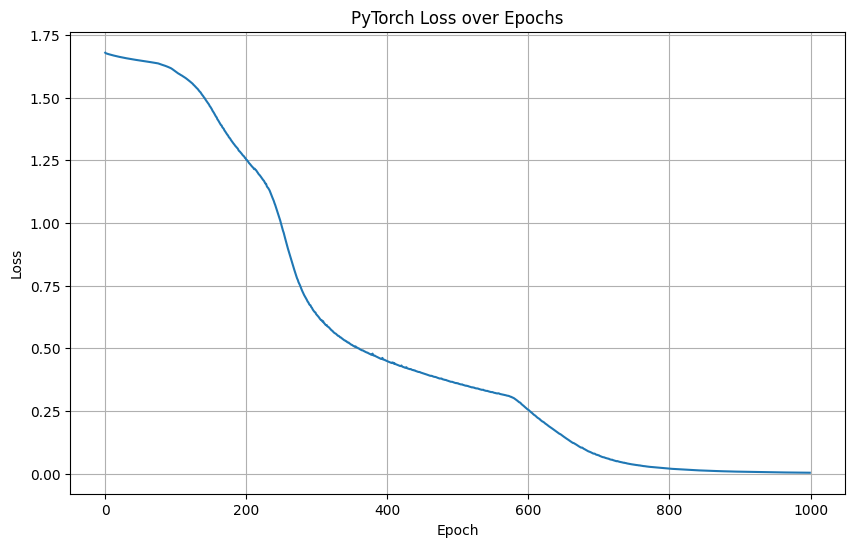

In [ ]:
# Plot the PyTorch losses
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses_pytorch)), losses_pytorch)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch Loss over Epochs")
plt.grid(True)
plt.show()

## Test the Trained PyTorch Model

Now that the model has been trained, let's test its performance on an input to see its predictions. We'll pass an input, get the raw logits from the model, and then convert them into probabilities using `torch.softmax` to determine the predicted class.

In [ ]:
# Select a test input from the training data (e.g., the first input)
test_input_index = 0
input_to_test = _in[test_input_index].unsqueeze(0) # Keep batch dimension
actual_target_class = _ot[test_input_index].item() # Get the actual class index

# Set the model to evaluation mode (important for layers like BatchNorm, Dropout)
model.eval()

# Perform a forward pass
with torch.no_grad(): # Disable gradient calculation for inference
    test_output_logits = model(input_to_test)
    test_probabilities = torch.softmax(test_output_logits, dim=1)

# Get the predicted class index
predicted_class_index = torch.argmax(test_probabilities, dim=1).item()

print(f"Test Input: {input_to_test.squeeze(0)}")
print(f"Raw Logits: {test_output_logits.squeeze(0).tolist()}")
print(f"Predicted Probabilities: {test_probabilities.squeeze(0).tolist()}")
print(f"Predicted Class Index: {predicted_class_index}")
print(f"Actual Target Class: {actual_target_class}")

# Compare prediction to actual target
if predicted_class_index == actual_target_class:
    print("Prediction: CORRECT")
else:
    print("Prediction: INCORRECT")

Test Input: tensor([1., 0., 0., 0., 0.])
Raw Logits: [2.4437906742095947, -18.17955780029297, -27.931163787841797, -15.058180809020996, -3.3528878688812256]
Predicted Probabilities: [0.996971607208252, 1.101733149155848e-09, 6.412210850183578e-14, 2.4984625923707426e-08, 0.0030284281820058823]
Predicted Class Index: 0
Actual Target Class: 0
Prediction: CORRECT


In [ ]:
# @title
import torch
import torch.nn as nn

# 1. Define a simple network
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 2)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

model = SimpleNet()

# 2. Dictionary to store captured activations
activation_store = {}

# 3. Define the hook function
# PyTorch passes three arguments to forward hooks: (layer, input_tensor, output_tensor)
def get_activation(name):
    def hook(module, input, output):
        # Store a copy of the layer's output tensor
        activation_store[name] = output.detach()
    return hook

# 4. Attach the hook to 'fc1' layer
handle = model.fc1.register_forward_hook(get_activation('fc1_layer'))

# 5. Run a forward pass
x = torch.randn(1, 5) # dummy input
output = model(x)

# 6. Inspect what was captured!
print("Captured fc1 Activations Shape:", activation_store['fc1_layer'].shape)
print("Captured fc1 Raw Data:\n", activation_store['fc1_layer'])

# 7. Clean up the hook when done (good practice)
handle.remove()

Captured fc1 Activations Shape: torch.Size([1, 10])
Captured fc1 Raw Data:
 tensor([[ 0.2898,  0.3620, -0.1415, -0.6471,  1.1340,  0.6871, -0.2294,  1.3400,
          0.0496, -0.1061]])


#lenet-1989

##using numpy and cpu

In [76]:
import numpy as np

class conv2d_node:
    def __init__(self, in_channel, out_channel, kernel_l, kernel_b, stride=1, padding=0, rng=None):
        if rng is None:
            rng = np.random.default_rng()
        self.kernel_l = kernel_l  # Kernel width
        self.kernel_b = kernel_b  # Kernel height
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.stride = stride

        # Support either integer padding (same for height & width) or a tuple (pad_h, pad_w)
        if isinstance(padding, int):
            self.pad_h = self.pad_w = padding
        else:
            self.pad_h, self.pad_w = padding

        # Weights: out_channel x in_channel x kernel_b x kernel_l
        self.weight = [
            [
                [
                    [node(rng.uniform(-0.5, 0.5)) for _ in range(kernel_l)]
                    for _ in range(kernel_b)
                ]
                for _ in range(in_channel)
            ]
            for _ in range(out_channel)
        ]

        # Bias: out_channel (one per output channel)
        self.bias = [node(0.0) for _ in range(out_channel)]

    def __call__(self, input_x):
        # Convert input_x to a numpy array.
        # If input_x is a list of arrays (e.g., [dummy_image]), np.array will make it (1, H, W).
        # If input_x is already a np.ndarray (e.g., output of previous conv), it stays as is.
        input_np = np.array(input_x)
        # print(f"input_np shape: {input_np.shape}")

        # If the input is a 2D array (H, W), assume it's a single-channel image and add a channel dimension.
        # print(f"input dimension{input_np.ndim}")
        if input_np.ndim == 2:
            input_np = np.expand_dims(input_np, axis=0) # Now (1, H, W)
        # print(f"input dimension{input_np.ndim}")

        # After this, input_np should always be (channels, H, W)
        if input_np.ndim > 3:
             raise ValueError(f"Input to conv2d_node must be 2D (H,W) or 3D (C,H,W), but got shape {input_np.shape}")

        # H, W are now correctly referring to the height and width of the image channels
        H, W = input_np.shape[1], input_np.shape[2]


        # Apply zero-padding to spatial dimensions (H, W) if pad > 0
        if self.pad_h > 0 or self.pad_w > 0:
            input_np = np.pad(
                input_np,
                ((0, 0), (self.pad_h, self.pad_h), (self.pad_w, self.pad_w)),
                mode='constant',
                constant_values=0.0
            )
        #3d img
        H, W = input_np.shape[1], input_np.shape[2]
        #2d img
        # H, W = input_np.shape[0], input_np.shape[1]

        # Calculate output spatial dimensions
        o_H = int((H - self.kernel_b) / self.stride + 1)
        o_W = int((W - self.kernel_l) / self.stride + 1)

        # Pre-flatten weights once per forward pass to minimize Python loop overhead
        flat_weights = [
            [np.array(self.weight[i][j]).flatten() for j in range(self.in_channel)]
            for i in range(self.out_channel)
        ]

        output_feature_maps = []
        for i in range(self.out_channel):
            feature_map = []
            for h_out in range(o_H):
                row = []
                for w_out in range(o_W):
                    h_start = h_out * self.stride
                    w_start = w_out * self.stride

                    terms = []
                    for j in range(self.in_channel):
                        # Extract and flatten input patch
                        patch_flat = input_np[
                            j,
                            h_start : h_start + self.kernel_b,
                            w_start : w_start + self.kernel_l
                        ].flatten()

                        terms.extend(
                            wt_e * in_e
                            for in_e, wt_e in zip(patch_flat, flat_weights[i][j])
                        )

                    # Sum products across all channels and add bias ONCE per output pixel
                    output_pixel = sum(terms, self.bias[i])
                    row.append(output_pixel)
                feature_map.append(row)
            output_feature_maps.append(feature_map)

        return np.array(output_feature_maps)

    def parameters(self):

        """Returns all learnable scalar nodes for optimization."""
        params = list(self.bias)
        for oc in range(self.out_channel):
            for ic in range(self.in_channel):
                for r in range(self.kernel_b):
                    for c in range(self.kernel_l):
                        params.append(self.weight[oc][ic][r][c])
        return params

In [ ]:
# @title
class conv2d_node:
  #[array][kernel] = [output]
  def __init__(self, in_channel, out_channel, kernel_l, kernel_b, rng=None, stride=1):
    if rng is None:
      rng = np.random.default_rng()
    self.kernel_l = kernel_l # Kernel length (width)
    self.kernel_b = kernel_b # Kernel breadth (height)
    self.in_channel = in_channel
    self.out_channel = out_channel
    self.stride = stride
    # Weights: out_channel x in_channel x kernel_b x kernel_l
    self.weight = [[[[node(rng.uniform(-1,1))for _ in range(kernel_l)]
                   for _ in range(kernel_b)]
                   for _ in range(in_channel)]
                  for _ in range(out_channel)]
    # Bias: out_channel (one bias per output feature map)
    self.bias = [node(rng.uniform(-1,1)) for _ in range(out_channel)] # Corrected bias initialization

  def __call__(self, input):
    input_np = np.array(input) # Convert list of lists to numpy array for 2D slicing
    # Assuming input_np shape is (in_channel, H, W)
    H, W = input_np.shape[1], input_np.shape[2] # Correctly get H and W from input_np


    # o_H is output height, o_W is output width
    o_H = int((H - self.kernel_b)/self.stride +1)
    o_W = int((W - self.kernel_l)/self.stride +1)

#correct##############block

    # Pre-flatten weights once per channel pair outside the spatial loops
    flat_weights = [
        [np.array(self.weight[i][j]).flatten() for j in range(self.in_channel)]
        for i in range(self.out_channel)
    ]
    output_feature_maps = []
    for i in range(self.out_channel):
        feature_map = []
        for h_out in range(o_H):
            row = []
            for w_out in range(o_W):
                h_start = h_out * self.stride
                w_start = w_out * self.stride

                terms = []
                for j in range(self.in_channel):
                    # Extract input patch and flatten
                    patch_flat = input_np[j, h_start : h_start + self.kernel_b, w_start : w_start + self.kernel_l].flatten()

                    # Multiply with the pre-flattened weight array
                    terms.extend(in_e * wt_e for in_e, wt_e in zip(patch_flat, flat_weights[i][j]))

                output_pixel = sum(terms, self.bias[i])
                row.append(output_pixel)
            feature_map.append(row)
        output_feature_maps.append(feature_map)
    return output_feature_maps
#correct##############block

  def parameters(self):
      params = []
      # Collect all bias nodes
      params.extend(self.bias)
      # Flatten and collect all weight nodes
      for oc in range(self.out_channel):
          for ic in range(self.in_channel):
              for r in range(self.kernel_b):
                  for c in range(self.kernel_l):
                      params.append(self.weight[oc][ic][r][c])
      return params

In [ ]:
# @title
#correct, weight is flattened once
#correct##############block

    o = np.array([ # This is the outer loop for output channels
        [ # This is the outer loop for output height
            [ # This is the outer loop for output width
                sum(
                    ( # This sum iterates through input channels and then flattens the kernel and input patch
                        wt_e * in_e
                        for j in range(self.in_channel)
                        for in_e, wt_e in zip(
                            input_np[j, h_start : h_start + self.kernel_b, w_start : w_start + self.kernel_l].flatten(),
                            np.array(self.weight[i][j]).flatten()
                        )
                    ),
                    self.bias[i]  # Initialize sum with bias[i] (adds bias ONCE per output pixel)
                )
                for w_start in range(0, o_W * self.stride, self.stride)
            ]
            for h_start in range(0, o_H * self.stride, self.stride)
        ]
        for i in range(self.out_channel)
      ])
return o
#correct##############block


In [ ]:
# @title
#test - initial trial
    o = np.array([sum(
    np.array([np.array([np.array([ sum(wt_e*in_e for in_e, wt_e in
    zip(input[j][h:h+self.kernel_b, w:w+self.kernel_l].flatten(), # Corrected slicing: [height:height+kernel_b, width:width+kernel_l]
    np.array(self.weight[i][j]).flatten()))
    for w in range(0, o_W * self.stride, self.stride)]) # The loop range needs to account for stride here for input indices
    for h in range(0, o_H * self.stride, self.stride)]) # The loop range needs to account for stride here for input indices
    + self.bias[i][j]
         for j in range(self.in_channel)]))
        for i in range(self.out_channel)])



In [ ]:
# @title
#correct code
    # output_feature_maps = []
    # for i in range(self.out_channel): # Iterate over output channels
    #     feature_map = []
    #     for h_out in range(o_H): # Iterate over output height
    #         row = []
    #         for w_out in range(o_W): # Iterate over output width
    #             # Calculate the current receptive field coordinates in the input
    #             h_start = h_out * self.stride
    #             w_start = w_out * self.stride

    #             # Initialize sum for this output pixel (across all input channels)
    #             convolution_sum_for_pixel = node(0.0) # Start with a node for summation

    #             for j in range(self.in_channel): # Iterate over input channels
    #                 # Extract the patch from the current input channel
    #                 input_patch = input_np[j, h_start:h_start+self.kernel_b, w_start:w_start+self.kernel_l]

    #                 # Get the corresponding weights for this output channel 'i' and input channel 'j'
    #                 kernel_weights = np.array(self.weight[i][j]) # This is a kernel_b x kernel_l matrix of nodes

    #                 # Perform element-wise multiplication and sum for this patch
    #                 patch_convolution = sum(
    #                     wt_e * in_e
    #                     for in_e, wt_e in zip(input_patch.flatten(), kernel_weights.flatten())
    #                 )
    #                 convolution_sum_for_pixel += patch_convolution # Accumulate sum across input channels

    #             # Add bias after summing over all input channels for this output pixel
    #             output_pixel = convolution_sum_for_pixel + self.bias[i]
    #             row.append(output_pixel)
    #         feature_map.append(row)
    #     output_feature_maps.append(np.array(feature_map)) # Convert inner list to numpy array

    # o = np.array(output_feature_maps) # Final output shape: out_channel x o_H x o_W

    o = np.array([
        [
            [
                sum(
                    (


In [ ]:
# @title
#correct##############block

# Pre-flatten weights once per channel pair outside the spatial loops
flat_weights = [
    [np.array(self.weight[i][j]).flatten() for j in range(self.in_channel)]
    for i in range(self.out_channel)
]

output_feature_maps = []
for i in range(self.out_channel):
    feature_map = []
    for h_out in range(o_H):
        row = []
        for w_out in range(o_W):
            h_start = h_out * self.stride
            w_start = w_out * self.stride

            terms = []
            for j in range(self.in_channel):
                # Extract input patch and flatten
                patch_flat = input_np[j, h_start : h_start + self.kernel_b, w_start : w_start + self.kernel_l].flatten()

                # Multiply with the pre-flattened weight array
                terms.extend(in_e * wt_e for in_e, wt_e in zip(patch_flat, flat_weights[i][j]))

            output_pixel = sum(terms, self.bias[i])
            row.append(output_pixel)
        feature_map.append(row)
    output_feature_maps.append(feature_map)

###testing

In [ ]:
inp = [[[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]],
      [[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]],
      [[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]]]

conv = conv2d_node(3, 1, 2, 2, stride=1, padding=1)




In [ ]:
o = conv(inp)
print(f"input:{inp}")
print(f"input shape:{len(inp)},{len(inp[0])},{len(inp[0][0])}")
print(f"stride:{1}")
print(f"padding:{1}")

print(f"weight:{conv.weight}")
print(f"weight shape:{len(conv.weight)},{len(conv.weight[0])},{len(conv.weight[0][0])}")

print(f"bias:{len(conv.bias)}")
print(f"output:{o}")
# print(f"output shape:{o.shape}")

input:[[[1, 2, 3], [4, 5, 6], [7, 8, 9]], [[1, 2, 3], [4, 5, 6], [7, 8, 9]], [[1, 2, 3], [4, 5, 6], [7, 8, 9]]]
input shape:3,3,3
stride:1
padding:1
weight:[[[[-0.003309167198274676, -0.41484055908245365], [0.014760502698265454, -0.12122094029857144]], [[-0.20440800329340747, 0.44826311352049386], [0.37657897844138544, -0.1438991534740841]], [[-0.3574647750312311, 0.46947482675964947], [0.28892684769775123, -0.34640674116932535]]]]
weight shape:1,3,2
bias:1
output:[[[-0.6115268349419809 -0.5427873410465597 -0.47404784715113835
   2.0407989865122063]
  [-1.9432099585702338 0.10404395751216988 0.11049888708236821
   2.386052136455673]
  [-2.269098319803107 0.1234087462227631 0.1298636757929601
   2.7313052863991394]
  [3.5202816683838276 0.06690543092112433 0.004620866595901774
   -5.086637509706219]]]


###Lesnet - 1

In [80]:
class LeNet1989:
    def __init__(self, rng=None):
        if rng is None:
            rng = np.random.default_rng(42)

        # Layer 1: 1 input channel -> 12 feature maps, 5x5 kernel, stride 2
        # Input: 1 x 16 x 16  ---> Output: 12 x 6 x 6
        #weight - 12x1x5x5
        self.conv1 = conv2d_node(in_channel=1, out_channel=12, kernel_l=5, kernel_b=5, stride=2, rng=rng)

        # Layer 2: 12 input channels -> 12 feature maps, 5x5 kernel, stride 2
        # Input: 12 x 6 x 6   ---> Output: 12 x 1 x 1
        #weight - 12x12x5x5
        self.conv2 = conv2d_node(in_channel=12, out_channel=12,  kernel_l=5, kernel_b=5, stride=2, rng=rng)

        # Layer 3: Fully Connected Layer
        # Input: 12 flattened nodes (12 * 1 * 1) -> 10 Output Neurons
        self.fc = layer(n_wt=12, n_neu_l=10, nonlin=False, rng=rng)

    def forward(self, x_img):
        """
        x_img: 2D numpy array or list of shape (16, 16)
        """
        # 1. Convert raw input values to an array of `node` objects
        # x_img from X_train is a (1, 16, 16) numpy array of floats.
        # Convert these floats into a 3D structure of node objects.
        # x_nodes = []
        # for c in range(x_img.shape[0]): # Iterate over channels
        #     channel_nodes = []
        #     for r in range(x_img.shape[1]): # Iterate over height
        #         row_nodes = []
        #         for col in range(x_img.shape[2]): # Iterate over width
        #             row_nodes.append(node(float(x_img[c, r, col]))) # Create node from float value
        #         channel_nodes.append(row_nodes)
        #     x_nodes.append(channel_nodes) # x_nodes is now a list of lists of lists of node objects, shape (C, H, W)

        # 2. First Convolutional Stage
        c1_out = self.conv1(x_img) # Shape: (12, 6, 6)
        # c1_out = self.conv1(x_nodes) # Shape: (12, 6, 6)

        # 3. Second Convolutional Stage
        c2_out = self.conv2(c1_out)  # Shape: (12, 1, 1)

        # 4. Flatten (12 x 1 x 1 -> 12 elements)
        flattened = [c2_out[oc][0][0] for oc in range(12)]

        # 5. Fully Connected Output Layer
        logits = self.fc(flattened)  # List of 10 `node` objects

        return logits

    def parameters(self):
        return self.conv1.parameters() + self.conv2.parameters() + self.fc.parameter()

###sub-test 1

In [78]:
# Create model and dummy dataset sample (16x16 pixel image)
rng = np.random.default_rng(42)
model = LeNet1989(rng=rng)
# loss_fn = cross_entropy_loss()
loss_fn = mse_loss()

# Dummy input image (16x16) and target (class index 3)
dummy_image = rng.uniform(0, 1, (16, 16))
target_onehot = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] # Class 3


In [55]:
for epoc in range(100):
  # 1. Forward Pass
  logits = model.forward(dummy_image)

  # 2. Calculate Loss using your Loss module
  total_loss = loss_fn(logits, target_onehot, 10)

  print(f"Forward Pass Loss: {total_loss._data:.4f}")

  # 3. Backward Pass (Backpropagate gradients back to early Conv weights)
  total_loss.backward()

  # 4. Verify Gradient Flow to First Conv Layer Weights
  # first_conv_weight = model.conv1.weight[0][0][0][0]
  # print(f"Gradient of first Conv1 weight: {first_conv_weight._grad:.6f}")
  # print(f"Total Learnable Parameters: {len(model.parameters())}")

  for p in model.parameters():
    p._data -= 0.001*p._grad

Forward Pass Loss: 4.5732
Forward Pass Loss: 6.6369
Forward Pass Loss: 3.0917
Forward Pass Loss: 1.3460
Forward Pass Loss: 4.9683
Forward Pass Loss: 6.6951
Forward Pass Loss: 4.3368
Forward Pass Loss: 3.2067
Forward Pass Loss: 4.5777
Forward Pass Loss: 4.8479
Forward Pass Loss: 3.0026
Forward Pass Loss: 1.9013
Forward Pass Loss: 3.2662
Forward Pass Loss: 5.3211
Forward Pass Loss: 5.5610
Forward Pass Loss: 4.1022
Forward Pass Loss: 3.1078
Forward Pass Loss: 3.7828
Forward Pass Loss: 5.1574
Forward Pass Loss: 5.4938
Forward Pass Loss: 4.2036
Forward Pass Loss: 2.2013
Forward Pass Loss: 0.8030
Forward Pass Loss: 0.7224
Forward Pass Loss: 1.8369
Forward Pass Loss: 3.4009
Forward Pass Loss: 4.4570
Forward Pass Loss: 4.3761
Forward Pass Loss: 3.2622
Forward Pass Loss: 1.8578
Forward Pass Loss: 0.9532
Forward Pass Loss: 0.7966
Forward Pass Loss: 1.0570
Forward Pass Loss: 1.3467
Forward Pass Loss: 1.6399
Forward Pass Loss: 2.0791
Forward Pass Loss: 2.5782
Forward Pass Loss: 2.8271
Forward Pass

In [58]:
logits = model.forward(dummy_image)
soft_max = SoftmaxLayerK()
logits = soft_max(logits)
print(np.argmax([n._data for n in logits]))
print(logits)

0
[0.5072252876793132, 0.0058487177267082325, 0.006655899852478305, 0.3925987543127267, 0.012464823474672185, 0.034522632734415006, 0.008289911835011765, 0.01564425479493402, 0.004962576519347497, 0.01178714107039297]


###sub-test 2

dataset extraction

In [81]:
import torchvision
import torchvision.transforms as transforms
#load standard minist and convert to numpy array normalized to [0,1]
transform = transforms.Compose({
    transforms.Resize((16,16)), #resiz the image to 16x16
    transforms.ToTensor()
})

dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                     transform=transform)
#dataset for verification
sample=20
X_train =[]
y_train=[]
for i in range(sample):
  img, label = dataset[i]
  X_train.append(np.array(img))
  y_train.append(label)

print(f"Dataset ready: {len(X_train)} samples of shape {X_train[0].shape}")

Dataset ready: 20 samples of shape (1, 16, 16)


/tmp/ipykernel_989/3287292347.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  X_train.append(np.array(img))


In [82]:
model = LeNet1989()

LEARNING_RATE = 0.01
EPOCHS = 30

# mse_loss_func = mse_loss() # Instantiate mse_loss
cross_entropy_loss_func = cross_entropy_loss() # Instantiate cross_entropy_loss
# soft_max = SoftmaxLayerK() # Softmax is now handled internally by cross_entropy_loss for training

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    correct = 0
    params = model.parameters()  # Directly fetch all nodes across conv1, conv2, and fc

    for x_sample, label in zip(X_train, y_train):
        # 1. Zero gradients
        for p in params:
            p._grad = 0.0

        # 2. Forward pass
        logits = model.forward(x_sample) # These are raw logits

        # 3. Prepare target as one-hot vector and compute loss
        num_classes = 10 # Assuming 10 output classes for LeNet1989
        target_one_hot = [0] * num_classes
        target_one_hot[label] = 1 # Convert integer label to one-hot
        print(target_one_hot)
        # cross_entropy_loss_func expects raw logits and a one-hot target
        loss_node = cross_entropy_loss_func(logits, target_one_hot)
        epoch_loss += loss_node._data

        # 4. Backward pass
        loss_node.backward()

        #debug##########
        # Insert inside epoch loop after loss.backward():
        # grads = [p._grad for p in model.parameters()]
        # print("Max gradient magnitude:", max(abs(g) for g in grads))
        # print("First parameter weight sample:", list(model.parameters())[0]._data)
        ###############

        # 5. Optimizer step
        for p in params:
            p._data -= LEARNING_RATE * p._grad

        # 6. Track accuracy
        # For accuracy tracking, apply softmax to get probabilities from raw logits
        temp_soft_max_for_accuracy = SoftmaxLayerK() # Create a temporary softmax layer for inference
        probabilities_for_accuracy = temp_soft_max_for_accuracy(logits)
        if np.argmax([n._data for n in probabilities_for_accuracy]) == label:
            correct += 1

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {epoch_loss/len(X_train):.4f} | Acc: {correct/len(X_train)*100:.1f}%")

[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Epoch 01/30 | Loss: 7.8959 | Acc: 10.0%
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

KeyboardInterrupt: 

0


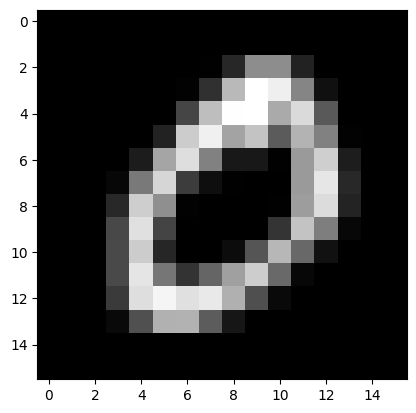

0


In [96]:
# print(len(X_train))
logits = model.forward(X_train[1]) # These are raw logits
soft_max = SoftmaxLayerK()
logits = soft_max(logits)
position = np.argmax([n._data for n in logits])
print(np.argmax([n._data for n in logits]))
plt.imshow(X_train[1][0], cmap='gray')
plt.show()
# print(y_train[position])
print(y_train[1])


##using pytorch and GPU

In [ ]:
#devuce configuration
device = torch.device('cuda' if torch.device.cuda.is_available() else 'cpu')
